Name - Sandesh Arun Mohite

Roll No - 23

Division - T.Y(AIML)-A

**Train and save the model**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from mpl_toolkits.mplot3d import Axes3D

In [7]:
df = pd.read_csv("/content/drive/MyDrive/Housing.csv")

In [8]:
df.shape

(545, 3)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   area      545 non-null    int64
 1   bedrooms  545 non-null    int64
 2   price     545 non-null    int64
dtypes: int64(3)
memory usage: 12.9 KB


In [10]:
df.head()

,area,bedrooms,price
0,7420,4,13300000
1,8960,4,12250000
2,9960,3,12250000
3,7500,4,12215000
4,7420,4,11410000


In [11]:
df.describe()

,area,bedrooms,price
count,545.000000,545.000000,5.450000e+02
mean,5150.541284,2.965138,4.766729e+06
std,2170.141023,0.738064,1.870440e+06
min,1650.000000,1.000000,1.750000e+06
25%,3600.000000,2.000000,3.430000e+06
50%,4600.000000,3.000000,4.340000e+06
75%,6360.000000,3.000000,5.740000e+06
max,16200.000000,6.000000,1.330000e+07


In [12]:
#Define features (X) and target (y)
X = df[['area', 'bedrooms']]   # independent variables
y = df['price']        # dependent variable

In [13]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
#Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [15]:
#Predictions
y_pred = model.predict(X_test)

In [16]:
#Evaluation
print("Coefficients (slopes):", model.coef_)
print("Intercept:", model.intercept_)
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

Coefficients (slopes): [3.89225730e+02 6.95678667e+05]
Intercept: 642086.4086518651
Mean Squared Error (MSE): 3280176595474.013
R² Score: 0.3510473817558726


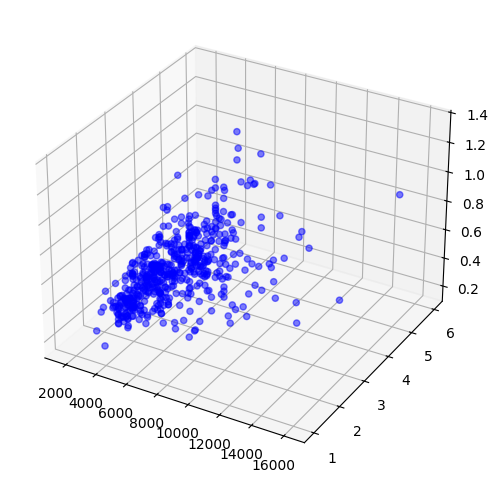

In [17]:
#Visualisation (3D Scatter + Regression Plane)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X['area'], X['bedrooms'], y, c='blue', marker='o', alpha=0.5, label="Actual")

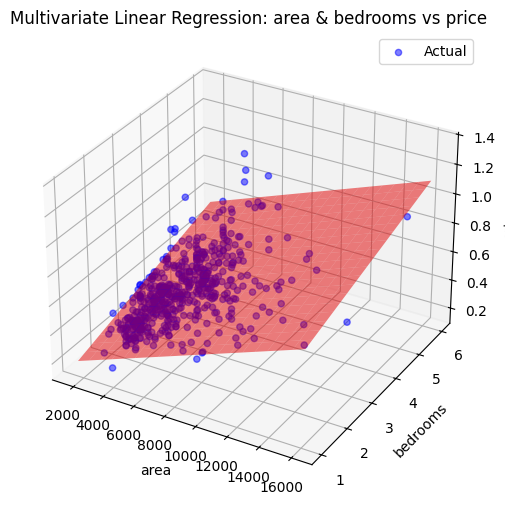

In [18]:
#Visualisation (3D Scatter + Regression Plane)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X['area'], X['bedrooms'], y, c='blue', marker='o', alpha=0.5, label="Actual")

# Create meshgrid for regression plane
area_range = np.linspace(X['area'].min(), X['area'].max(), 20)
bedrooms_range = np.linspace(X['bedrooms'].min(), X['bedrooms'].max(), 20)
area_grid, bedrooms_grid = np.meshgrid(area_range, bedrooms_range)
price_pred = model.intercept_ + model.coef_[0]*area_grid + model.coef_[1]*bedrooms_grid

ax.plot_surface(area_grid, bedrooms_grid, price_pred, color='red', alpha=0.5)

ax.set_xlabel('area')
ax.set_ylabel('bedrooms')
ax.set_zlabel('price')
ax.set_title("Multivariate Linear Regression: area & bedrooms vs price")
plt.legend()
plt.show()

In [19]:
#Prediction for a new house
new_house = np.array([[8000, 4]])  # example (area=8.5, bedrooms=120)
predicted_price = model.predict(new_house)
print("Predicted price for area=8000 and bedrooms=4:", predicted_price[0])

Predicted price for area=8000 and bedrooms=4: 6538606.917908867


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [20]:
import pickle

In [21]:
pickle.dump(model,open('MLRModel.pkl','wb'))

**Flask Code**

In [22]:
from flask import Flask, render_template, request
import pickle
import numpy as np

app = Flask(__name__)

# Load the trained Multiple Linear Regression model
model = pickle.load(open("MLRModel.pkl", "rb"))


@app.route('/')
def home():
    return render_template("index.html")


@app.route('/predict', methods=['POST'])
def predict():

    # Read inputs from the HTML form
    area = float(request.form['area'])
    bedrooms = float(request.form['bedrooms'])

    # Predict price
    prediction = model.predict(np.array([[area, bedrooms]]))

    return render_template(
        "index.html",
        prediction_text=f"Predicted price : {prediction[0]:.2f} LPA"
    )


if __name__ == "__main__":
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


**HTML Code**

In [23]:
<!DOCTYPE html>
<html lang="en">

<head>

    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Student price Predictor</title>

    <style>

        *{
            margin:0;
            padding:0;
            box-sizing:border-box;
            font-family:Arial, Helvetica, sans-serif;
        }

        body{

            background:#f4f7fc;
            display:flex;
            justify-content:center;
            align-items:center;
            height:100vh;

        }

        .container{

            width:430px;
            background:white;
            padding:35px;
            border-radius:15px;
            box-shadow:0 10px 25px rgba(0,0,0,.2);

        }

        h1{

            text-align:center;
            color:#0d47a1;
            margin-bottom:8px;

        }

        h3{

            text-align:center;
            color:#555;
            margin-bottom:25px;

        }

        label{

            font-weight:bold;
            display:block;
            margin-top:12px;
            margin-bottom:6px;

        }

        input{

            width:100%;
            padding:12px;
            border:1px solid #ccc;
            border-radius:8px;
            font-size:16px;

        }

        button{

            width:100%;
            margin-top:25px;
            padding:12px;
            font-size:18px;
            background:#1565c0;
            color:white;
            border:none;
            border-radius:8px;
            cursor:pointer;
            transition:.3s;

        }

        button:hover{

            background:#0d47a1;

        }

        .result{

            margin-top:25px;
            background:#e8f5e9;
            color:green;
            padding:15px;
            border-radius:8px;
            text-align:center;
            font-size:20px;
            font-weight:bold;

        }

        footer{

            text-align:center;
            margin-top:20px;
            color:#777;
            font-size:13px;

        }

    </style>

</head>

<body>

<div class="container">

    <h1>House Preice Predictor</h1>

    <h3>Multiple Linear Regression</h3>

    <form action="/predict" method="POST">

        <label>Enter Student area</label>

        <input
            type="number"
            name="area"
            step="100"
            placeholder="Example : 8000"
            required>

        <label>Enter bedrooms Score</label>

        <input
            type="number"
            name="bedrooms"
            placeholder="Example : 4"
            required>

        <button type="submit">

            Predict price

        </button>

    </form>

    {% if prediction_text %}

    <div class="result">

        {{ prediction_text }}

    </div>

    {% endif %}

    <footer>

    </footer>

</div>

</body>
</html>

SyntaxError: invalid decimal literal (1644784435.py, line 26)